In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback, DataCollatorWithPadding
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', 20)

In [2]:
# 1. Создаём свой класс Dataset для PyTorch
class IntentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Токенизируем текст
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            # padding=False,
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [3]:
import pandas as pd

df = pd.read_csv('../dataset/extended_by_deepseek_3.csv', sep=',')
df = df[df['тема'].notna()]
df = df[df['текст'].notna()]
df = df[['тема', 'текст']]

# темы, по которым пока не был получен ответ от deepseek:
df = df[df['тема'] != "вышка тура"]
df = df[df['тема'] != "плиткорез электрический"]
df = df[df['тема'] != "реноватор аккумуляторный"]
df = df[df['тема'] != "присоска"]
df = df[df['тема'] != "нивелир оптический"]
df = df[df['тема'] != "детектор проводки"]
df = df[df['тема'] != "дрель магнитная"]

# df = df[df['тема'] != "не вопрос клиента"]
df

,тема,текст
0,дрель-шуруповерт,"добрый вечер! подскажите, у вас можно взять в ..."
1,пылесос,Здравствуйте) сколько стоит аренда строительно...
2,плиткорез ручной,Доброе утро. Подскажите пожалуйста в какую цен...
3,фен,Доброе утро Есть строительный фен на аккумулят...
4,не вопрос клиента,Добрый день
...,...,...
1492,пароочиститель,"'Здравствуйте, есть ли в прокате устройство д..."
1493,пароочиститель,"'Привет, сколько стоит арендовать пароочистит..."
1494,пароочиститель,"'Добрый день, нужен пароочиститель для уборки..."
1495,пароочиститель,"'Здравствуйте, подскажите, можно ли взять пар..."


In [4]:
def clear_text(text: str) -> str:
    # функция очистки текстов от паразитных слов, не относящихся к теме запроса
    
    trash_values = [
        'добрый вечер', 
        'добрый день', 
        'доброе утро',
        'добрый утро',
        'здравствуйте',
        'подскажите',
        'пожалуйста',
        'хотелось',
        'интересует',
        'нужен',
        'нужно',
        'хочу',
        'надо',
        'можно',
        'аренда',
        'аренду',
        'хочу',
        'хотел бы',
        'в наличии',
        'сколько стоит',
        ',',
        "'",
    ]
    text = text.lower()
    for value in trash_values:
        text = text.replace(value, '')
    return text

In [5]:
df['текст'] = df['текст'].map(clear_text)
df

,тема,текст
0,дрель-шуруповерт,! у вас взять в шурповерт?
1,пылесос,) строительного пылесоса на сутки?
2,плиткорез ручной,. в какую цену у вас следующие инструменты: ...
3,фен,есть строительный фен на аккумуляторной батареи?
4,не вопрос клиента,
...,...,...
1492,пароочиститель,есть ли в прокате устройство для чистки паро...
1493,пароочиститель,привет арендовать пароочиститель для чистки ...
1494,пароочиститель,пароочиститель для уборки после ремонта есть ?
1495,пароочиститель,ли взять пароочиститель на сутки?


In [6]:
df['номер темы'] = df['тема'].astype('category').cat.codes
df

,тема,текст,номер темы
0,дрель-шуруповерт,! у вас взять в шурповерт?,19
1,пылесос,) строительного пылесоса на сутки?,59
2,плиткорез ручной,. в какую цену у вас следующие инструменты: ...,51
3,фен,есть строительный фен на аккумуляторной батареи?,76
4,не вопрос клиента,,36
...,...,...,...
1492,пароочиститель,есть ли в прокате устройство для чистки паро...,42
1493,пароочиститель,привет арендовать пароочиститель для чистки ...,42
1494,пароочиститель,пароочиститель для уборки после ремонта есть ?,42
1495,пароочиститель,ли взять пароочиститель на сутки?,42


In [7]:
df_small = df[df['тема']=='бензорез']
df_small

,тема,текст,номер темы
34,бензорез,. бензорез у вас есть?,5
254,бензорез,у вас есть в бетонорез?,5
678,бензорез,бензорез под 400 диск хускварна. есть такой?,5
809,бензорез,. с большим диском по бетону на сутки по како...,5
881,бензорез,есть ли бензорез с 400 диском в на одни сутки?,5
1076,бензорез,бензорез для резки металла на завтра ?,5
1077,бензорез,\n есть ли у вас бензорез для демонтажа заб...,5
1078,бензорез,\nпривет взять бензорез на пару часов чтобы...,5
1079,бензорез,\n ли арендовать бензорез на выходные?,5
1080,бензорез,\n взять бензорез на сутки резать арматуру?,5


In [8]:
summary = df['тема'].value_counts()
print(summary)

тема
не вопрос клиента                126
перфоратор                        78
пылесос                           65
дрель-шуруповерт                  55
торцовочная пила                  45
                                ... 
сабельная пила аккумуляторная     11
домкрат подкатной                 11
миксер                            10
сварочный аппарат                 10
Отбойный молоток                  10
Name: count, Length: 82, dtype: int64


In [9]:
import numpy as np

# summary = df['тема'].value_counts()

mean_val = summary.mean()           # среднее арифметическое
variance_val = summary.var()        # дисперсия (по умолчанию ddof=1 — несмещённая)
std_val = summary.std()             # стандартное отклонение

# Или через numpy:
# mean_val = np.mean(summary)
# variance_val = np.var(summary, ddof=1)
# std_val = np.std(summary, ddof=1)

print(f"Среднее: {mean_val:.2f}")
print(f"Дисперсия: {variance_val:.2f}")
print(f"Стандартное отклонение: {std_val:.2f}")

Среднее: 18.24
Дисперсия: 275.89
Стандартное отклонение: 16.61


In [9]:
# Применяем маску: оставляем только те строки, где размер темы >= 5
mask = df.groupby('тема')['тема'].transform('size') >= 5
df = df[mask]
df['номер темы'] = df['тема'].astype('category').cat.codes
df

,тема,текст,номер темы
0,дрель-шуруповерт,! у вас взять в шурповерт?,19
1,пылесос,) строительного пылесоса на сутки?,59
2,плиткорез ручной,. в какую цену у вас следующие инструменты: ...,51
3,фен,есть строительный фен на аккумуляторной батареи?,76
4,не вопрос клиента,,36
...,...,...,...
1492,пароочиститель,есть ли в прокате устройство для чистки паро...,42
1493,пароочиститель,привет арендовать пароочиститель для чистки ...,42
1494,пароочиститель,пароочиститель для уборки после ремонта есть ?,42
1495,пароочиститель,ли взять пароочиститель на сутки?,42


In [10]:
summary = df['тема'].value_counts()
print(summary)

тема
не вопрос клиента                126
перфоратор                        78
пылесос                           65
дрель-шуруповерт                  55
торцовочная пила                  45
                                ... 
сабельная пила аккумуляторная     11
домкрат подкатной                 11
миксер                            10
сварочный аппарат                 10
Отбойный молоток                  10
Name: count, Length: 82, dtype: int64


In [11]:
labels_df = df[['номер темы', 'тема']]
labels_df = labels_df.drop_duplicates(subset=['номер темы'])
labels_df = labels_df.sort_values(by='номер темы')
labels_df

,номер темы,тема
906,0,Отбойный молоток
39,1,УШМ
41,2,УШМ аккумуляторная
361,3,бензобур
330,4,бензопила
...,...,...
105,77,фен аккумуляторный
155,78,фрезер
163,79,шлифовальная машина
636,80,шнек для бензобура


In [12]:
labels_df.to_csv('../dataset/labels.csv')

In [13]:
from sklearn.model_selection import train_test_split

train, temp = train_test_split(df, test_size=0.1, random_state=42)
val, test = train_test_split(temp, test_size=0.5, random_state=42)

print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

Train: 1346, Val: 75, Test: 75


In [14]:
train_texts = train['текст'].tolist()
train_labels = train['номер темы'].tolist()
val_texts = val['текст'].tolist()
val_labels = val['номер темы'].tolist()
test_texts = test['текст'].tolist()
test_labels = test['номер темы'].tolist()

In [15]:
# 4. Настраиваем параметры обучения
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,          
    per_device_train_batch_size=4, # маленький батч для CPU
    per_device_eval_batch_size=4,
    eval_strategy="epoch",
    save_strategy="epoch",
    dataloader_pin_memory=False,
    logging_steps=5,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
)

In [16]:
# 5. Функция для подсчёта метрик
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted', zero_division=0)
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }

In [17]:
training_results = {}

## Модель DeepPavlov/rubert-base-cased

In [18]:
# 2. Загружаем модель и токенизатор
import os
with open('hf_token.txt', encoding='utf-8') as f:
    token = f.read()
os.environ["HF_TOKEN"] = token
model_name = "DeepPavlov/rubert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(labels_df))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you

In [19]:
train_dataset = IntentDataset(train_texts, train_labels, tokenizer)
val_dataset = IntentDataset(val_texts, val_labels, tokenizer)
test_dataset = IntentDataset(test_texts, test_labels, tokenizer)

In [20]:
# 6. Запускаем обучение
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=10)]
)

print("🚀 Начинаем обучение...")
trainer.train()

🚀 Начинаем обучение...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,3.313069,3.448585,0.200000,0.181316,0.200000,0.163524
2,2.024452,2.165388,0.573333,0.483704,0.573333,0.511873
3,1.503568,1.310362,0.760000,0.726508,0.760000,0.724085
4,0.450076,0.961168,0.773333,0.795556,0.773333,0.759333
5,0.523655,0.878417,0.773333,0.784444,0.773333,0.761492
6,0.236623,0.592767,0.840000,0.873333,0.840000,0.841111
7,0.220350,0.540632,0.893333,0.924444,0.893333,0.898000
8,0.061057,0.679406,0.853333,0.895556,0.853333,0.862825
9,0.226927,0.647692,0.880000,0.924444,0.880000,0.890381
10,0.008638,0.505952,0.893333,0.917778,0.893333,0.894825


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=6740, training_loss=0.5120850275887607, metrics={'train_runtime': 1596.4051, 'train_samples_per_second': 16.863, 'train_steps_per_second': 4.222, 'total_flos': 1772009301504000.0, 'train_loss': 0.5120850275887607, 'epoch': 20.0})

In [21]:
# 7. Сохраняем модель
dir_name = model_name.replace('/', '_')
model.save_pretrained(os.path.join('..', 'models', dir_name))
tokenizer.save_pretrained(os.path.join('..', 'models', dir_name))

print("✅ Модель сохранена")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Модель сохранена


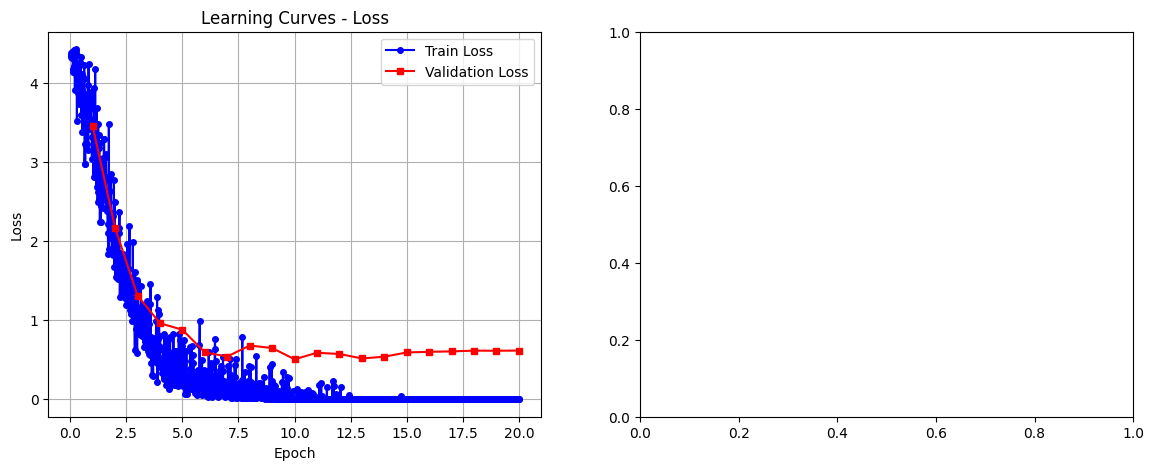

In [22]:
# Извлекаем историю обучения
log_history = trainer.state.log_history

# Разделяем train и eval логи
train_losses = []
eval_losses = []
eval_accuracies = []
eval_f1_scores = []
epochs_train = []
epochs_eval = []

for log in log_history:
    if 'loss' in log and 'epoch' in log:
        # Training loss
        train_losses.append(log['loss'])
        epochs_train.append(log['epoch'])
    
    if 'eval_loss' in log and 'epoch' in log:
        # Evaluation metrics
        eval_losses.append(log['eval_loss'])
        eval_accuracies.append(log.get('eval_accuracy', None))
        eval_f1_scores.append(log.get('eval_f1_weighted', None))
        epochs_eval.append(log['epoch'])

# Создаем графики
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Loss
axes[0].plot(epochs_train, train_losses, 'b-', label='Train Loss', marker='o', markersize=4)
axes[0].plot(epochs_eval, eval_losses, 'r-', label='Validation Loss', marker='s', markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Learning Curves - Loss')
axes[0].legend()
axes[0].grid(True)

In [ ]:
# device = torch.device("cpu")

# # 8. Тестируем модель на новых фразах
# def predict_intent(text, model, tokenizer):
#     model.to(device)
#     model.eval()
#     inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    
#     with torch.no_grad():
#         outputs = model(**inputs)
#         predictions = torch.softmax(outputs.logits, dim=-1)
#         # print(predictions)
#         predicted_class = torch.argmax(predictions, dim=-1).item()
#         confidence = predictions[0][predicted_class].item()
    
#     return predicted_class, confidence

# acc = 0
# for test_text, test_label in zip(test_texts, test_labels):
#     # print(test_text)
#     pred, conf = predict_intent(test_text, model, tokenizer)

#     if pred==test_label:
#         symbol = '🍏'
#     else:
#         symbol = '🍎'
    
#     print(f"{symbol} '{test_text}' -> {labels_df.loc[labels_df['номер темы'] == pred, 'тема'].values[0]} (уверенность: {conf:.2f})")
#     acc += pred==test_label
#     print (labels_df.loc[labels_df['номер темы'] == test_label, 'тема'])
# print(f'Точность: {acc/len(test_texts)}')

In [45]:
print(predictions.metrics)

{'test_loss': 4.951504230499268, 'test_accuracy': 0.0, 'test_precision': 0.0, 'test_recall': 0.0, 'test_f1': 0.0, 'test_runtime': 0.9132, 'test_samples_per_second': 82.131, 'test_steps_per_second': 20.806}


In [23]:
print("🔮 Делаем предсказания на тестовой выборке...")
model = model.to('mps')
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_labels

# f1_macro = f1_score(y_true, y_pred, average='macro')
# f1_weighted = f1_score(y_true, y_pred, average='weighted')
accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

print(f"\n📊 Общие метрики:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  precision: {precision:.4f}")
print(f"  recall: {recall:.4f}")
print(f"  f1: {f1:.4f}")

training_results[model_name] = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1
}

🔮 Делаем предсказания на тестовой выборке...



📊 Общие метрики:
  Accuracy: 0.8667
  precision: 0.9333
  recall: 0.8667
  f1: 0.8860


In [24]:
training_results

{'DeepPavlov/rubert-base-cased': {'accuracy': 0.8666666666666667,
  'precision': 0.9333333333333333,
  'recall': 0.8666666666666667,
  'f1': 0.8859682539682538}}

## Модель rubert-tiny2

In [66]:
# 2. Загружаем модель и токенизатор
import os
with open('hf_token.txt', encoding='utf-8') as f:
    token = f.read()
os.environ["HF_TOKEN"] = token
model_name = "cointegrated/rubert-tiny2"
tokenizer2 = AutoTokenizer.from_pretrained(model_name)
model2 = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(labels_df))

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider trai

In [54]:
train_dataset = IntentDataset(train_texts, train_labels, tokenizer2)
val_dataset = IntentDataset(val_texts, val_labels, tokenizer2)
test_dataset = IntentDataset(test_texts, test_labels, tokenizer2)

In [55]:
trainer2 = Trainer(
    model=model2,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=10)]
)

print("🚀 Начинаем обучение...")
trainer2.train()

🚀 Начинаем обучение...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,3.641397,3.674399,0.426667,0.331402,0.426667,0.330841
2,3.018207,2.983073,0.560000,0.466389,0.560000,0.483063
3,2.799759,2.523547,0.626667,0.495700,0.626667,0.543519
4,1.670456,2.175982,0.693333,0.591704,0.693333,0.624762
5,1.800321,1.859541,0.746667,0.684508,0.746667,0.694921
6,1.139685,1.624119,0.733333,0.659397,0.733333,0.676190
7,1.320136,1.419531,0.800000,0.755556,0.800000,0.761939
8,1.322204,1.276282,0.773333,0.735111,0.773333,0.730511
9,0.971156,1.155618,0.826667,0.806667,0.826667,0.797495
10,0.878826,1.035151,0.826667,0.800000,0.826667,0.797495


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.

TrainOutput(global_step=6740, training_loss=1.2109999886694578, metrics={'train_runtime': 228.1508, 'train_samples_per_second': 117.992, 'train_steps_per_second': 29.542, 'total_flos': 50146103930880.0, 'train_loss': 1.2109999886694578, 'epoch': 20.0})

In [56]:
# 7. Сохраняем модель
dir_name = model_name.replace('/', '_')
model2.save_pretrained(os.path.join('..', 'models', dir_name))
tokenizer2.save_pretrained(os.path.join('..', 'models', dir_name))

print("✅ Модель сохранена")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Модель сохранена


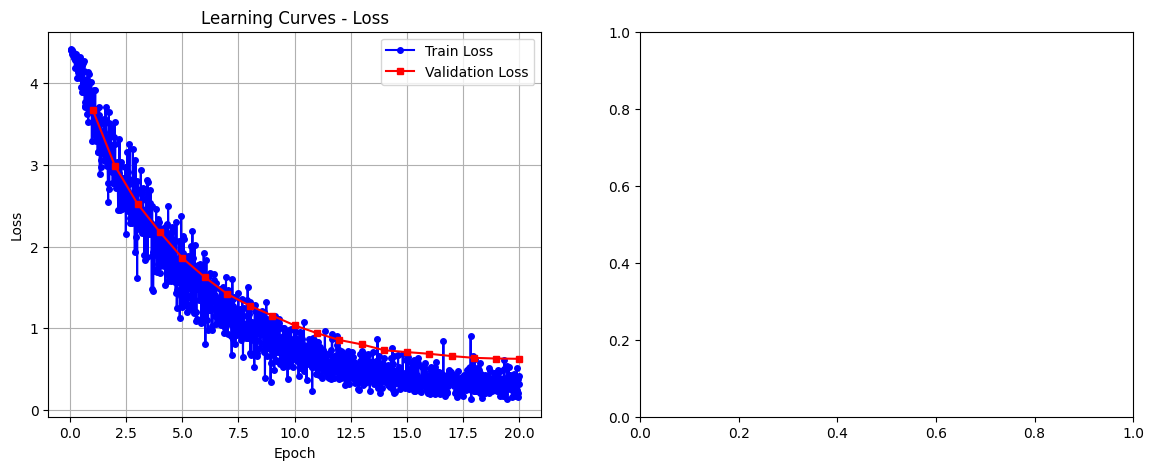

In [57]:
# Извлекаем историю обучения
log_history = trainer2.state.log_history

# Разделяем train и eval логи
train_losses = []
eval_losses = []
eval_accuracies = []
eval_f1_scores = []
epochs_train = []
epochs_eval = []

for log in log_history:
    if 'loss' in log and 'epoch' in log:
        # Training loss
        train_losses.append(log['loss'])
        epochs_train.append(log['epoch'])
    
    if 'eval_loss' in log and 'epoch' in log:
        # Evaluation metrics
        eval_losses.append(log['eval_loss'])
        eval_accuracies.append(log.get('eval_accuracy', None))
        eval_f1_scores.append(log.get('eval_f1_weighted', None))
        epochs_eval.append(log['epoch'])

# Создаем графики
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Loss
axes[0].plot(epochs_train, train_losses, 'b-', label='Train Loss', marker='o', markersize=4)
axes[0].plot(epochs_eval, eval_losses, 'r-', label='Validation Loss', marker='s', markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Learning Curves - Loss')
axes[0].legend()
axes[0].grid(True)

## Анализ метрик

In [67]:
print("🔮 Делаем предсказания на тестовой выборке...")
model2 = model2.to('mps')
predictions = trainer2.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_labels

# f1_macro = f1_score(y_true, y_pred, average='macro')
# f1_weighted = f1_score(y_true, y_pred, average='weighted')
accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

print(f"\n📊 Общие метрики:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  precision: {precision:.4f}")
print(f"  recall: {recall:.4f}")
print(f"  f1: {f1:.4f}")

training_results[model_name] = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1
}

🔮 Делаем предсказания на тестовой выборке...



📊 Общие метрики:
  Accuracy: 0.8000
  precision: 0.8744
  recall: 0.8000
  f1: 0.8190


In [68]:
training_results

{'cointegrated/rubert-tiny2': {'accuracy': 0.8,
  'precision': 0.8744444444444444,
  'recall': 0.8,
  'f1': 0.818984126984127},
 'DeepPavlov/rubert-base-cased': {'accuracy': 0.8133333333333334,
  'precision': 0.8977777777777777,
  'recall': 0.8133333333333334,
  'f1': 0.8234920634920635}}

## ai-forever/ruElectra-small

In [19]:
import os
with open('hf_token.txt', encoding='utf-8') as f:
    token = f.read()
os.environ["HF_TOKEN"] = token
model_name = "ai-forever/ruElectra-small"
tokenizer3 = AutoTokenizer.from_pretrained(model_name)
model3 = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(labels_df))

config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/174M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: ai-forever/ruElectra-small
Key                                                                | Status     | 
-------------------------------------------------------------------+------------+-
generator.encoder.layer.{0...11}.attention.output.dense.weight     | UNEXPECTED | 
generator.encoder.layer.{0...11}.output.LayerNorm.weight           | UNEXPECTED | 
generator.encoder.layer.{0...11}.attention.output.dense.bias       | UNEXPECTED | 
generator.encoder.layer.{0...11}.attention.self.value.weight       | UNEXPECTED | 
generator.encoder.layer.{0...11}.attention.self.key.bias           | UNEXPECTED | 
generator.encoder.layer.{0...11}.intermediate.dense.bias           | UNEXPECTED | 
generator.encoder.layer.{0...11}.attention.output.LayerNorm.bias   | UNEXPECTED | 
generator.encoder.layer.{0...11}.attention.self.query.bias         | UNEXPECTED | 
generator.encoder.layer.{0...11}.attention.self.query.weight       | UNEXPECTED | 
generator

model.safetensors:   0%|          | 0.00/173M [00:00<?, ?B/s]

In [20]:
train_dataset = IntentDataset(train_texts, train_labels, tokenizer3)
val_dataset = IntentDataset(val_texts, val_labels, tokenizer3)
test_dataset = IntentDataset(test_texts, test_labels, tokenizer3)

In [21]:
trainer3 = Trainer(
    model=model3,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=10)]
)

print("🚀 Начинаем обучение...")
trainer3.train()

🚀 Начинаем обучение...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,4.290854,4.314563,0.120000,0.058095,0.120000,0.062222
2,4.059774,4.144532,0.066667,0.013889,0.066667,0.022989
3,4.109604,3.962151,0.080000,0.012083,0.080000,0.020981
4,3.055174,3.791859,0.120000,0.041604,0.120000,0.057813
5,3.615423,3.678060,0.160000,0.073474,0.160000,0.086349
6,3.183038,3.572821,0.160000,0.073317,0.160000,0.086316
7,3.615995,3.507176,0.160000,0.085196,0.160000,0.099902
8,3.279097,3.401834,0.160000,0.080476,0.160000,0.096785
9,3.445934,3.337129,0.173333,0.097607,0.173333,0.110134
10,3.631243,3.294831,0.186667,0.150418,0.186667,0.144709


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

TrainOutput(global_step=6740, training_loss=3.231587948997226, metrics={'train_runtime': 459.9237, 'train_samples_per_second': 58.531, 'train_steps_per_second': 14.655, 'total_flos': 198419251752960.0, 'train_loss': 3.231587948997226, 'epoch': 20.0})

In [22]:
# 7. Сохраняем модель
dir_name = model_name.replace('/', '_')
model3.save_pretrained(os.path.join('..', 'models', dir_name))
tokenizer3.save_pretrained(os.path.join('..', 'models', dir_name))

print("✅ Модель сохранена")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Модель сохранена


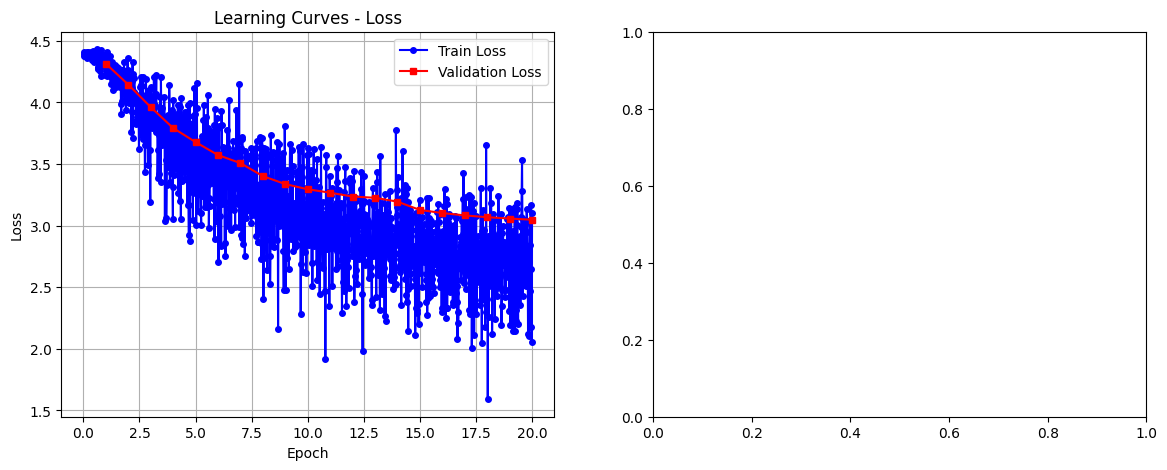

In [24]:
# Извлекаем историю обучения
log_history = trainer3.state.log_history

# Разделяем train и eval логи
train_losses = []
eval_losses = []
eval_accuracies = []
eval_f1_scores = []
epochs_train = []
epochs_eval = []

for log in log_history:
    if 'loss' in log and 'epoch' in log:
        # Training loss
        train_losses.append(log['loss'])
        epochs_train.append(log['epoch'])
    
    if 'eval_loss' in log and 'epoch' in log:
        # Evaluation metrics
        eval_losses.append(log['eval_loss'])
        eval_accuracies.append(log.get('eval_accuracy', None))
        eval_f1_scores.append(log.get('eval_f1_weighted', None))
        epochs_eval.append(log['epoch'])

# Создаем графики
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Loss
axes[0].plot(epochs_train, train_losses, 'b-', label='Train Loss', marker='o', markersize=4)
axes[0].plot(epochs_eval, eval_losses, 'r-', label='Validation Loss', marker='s', markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Learning Curves - Loss')
axes[0].legend()
axes[0].grid(True)

In [25]:
print("🔮 Делаем предсказания на тестовой выборке...")
model3 = model3.to('mps')
predictions = trainer3.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_labels

# f1_macro = f1_score(y_true, y_pred, average='macro')
# f1_weighted = f1_score(y_true, y_pred, average='weighted')
accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

print(f"\n📊 Общие метрики:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  precision: {precision:.4f}")
print(f"  recall: {recall:.4f}")
print(f"  f1: {f1:.4f}")

training_results[model_name] = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1
}

🔮 Делаем предсказания на тестовой выборке...



📊 Общие метрики:
  Accuracy: 0.2133
  precision: 0.1497
  recall: 0.2133
  f1: 0.1612


In [26]:
training_results

{'ai-forever/ruElectra-small': {'accuracy': 0.21333333333333335,
  'precision': 0.1497222222222222,
  'recall': 0.21333333333333335,
  'f1': 0.16121509209744503}}

In [19]:
import os
with open('hf_token.txt', encoding='utf-8') as f:
    token = f.read()
os.environ["HF_TOKEN"] = token
model_name = "ai-forever/ruElectra-medium"
tokenizer4 = AutoTokenizer.from_pretrained(model_name)
model4 = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(labels_df))

config.json:   0%|          | 0.00/734 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/356M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: ai-forever/ruElectra-medium
Key                                                                | Status     | 
-------------------------------------------------------------------+------------+-
generator.encoder.layer.{0...11}.attention.self.key.bias           | UNEXPECTED | 
generator.encoder.layer.{0...11}.intermediate.dense.bias           | UNEXPECTED | 
generator.encoder.layer.{0...11}.output.LayerNorm.bias             | UNEXPECTED | 
generator.encoder.layer.{0...11}.attention.self.value.bias         | UNEXPECTED | 
generator.encoder.layer.{0...11}.attention.output.dense.weight     | UNEXPECTED | 
generator.encoder.layer.{0...11}.output.dense.bias                 | UNEXPECTED | 
generator.encoder.layer.{0...11}.attention.self.query.bias         | UNEXPECTED | 
generator.encoder.layer.{0...11}.output.dense.weight               | UNEXPECTED | 
generator.encoder.layer.{0...11}.attention.self.query.weight       | UNEXPECTED | 
discrimi

model.safetensors:   0%|          | 0.00/356M [00:00<?, ?B/s]

In [20]:
train_dataset = IntentDataset(train_texts, train_labels, tokenizer4)
val_dataset = IntentDataset(val_texts, val_labels, tokenizer4)
test_dataset = IntentDataset(test_texts, test_labels, tokenizer4)

In [21]:
trainer4 = Trainer(
    model=model4,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=10)]
)

print("🚀 Начинаем обучение...")
trainer4.train()

🚀 Начинаем обучение...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,3.759457,3.793868,0.173333,0.058500,0.173333,0.081991
2,3.332584,3.280233,0.240000,0.185952,0.240000,0.180337
3,3.045089,2.775558,0.266667,0.220667,0.266667,0.217874
4,1.749447,2.264290,0.440000,0.386508,0.440000,0.393926
5,1.880524,1.824474,0.560000,0.507556,0.560000,0.513778
6,1.007321,1.467300,0.653333,0.626667,0.653333,0.625926
7,1.345522,1.157130,0.760000,0.733333,0.760000,0.738878
8,1.094154,1.012981,0.800000,0.795556,0.800000,0.781926
9,0.917426,0.892135,0.786667,0.786667,0.786667,0.774815
10,0.563235,0.834848,0.800000,0.791111,0.800000,0.787259


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

TrainOutput(global_step=6740, training_loss=1.0766233226743136, metrics={'train_runtime': 1022.4742, 'train_samples_per_second': 26.328, 'train_steps_per_second': 6.592, 'total_flos': 997473463726080.0, 'train_loss': 1.0766233226743136, 'epoch': 20.0})

In [22]:
# 7. Сохраняем модель
dir_name = model_name.replace('/', '_')
model4.save_pretrained(os.path.join('..', 'models', dir_name))
tokenizer4.save_pretrained(os.path.join('..', 'models', dir_name))

print("✅ Модель сохранена")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Модель сохранена


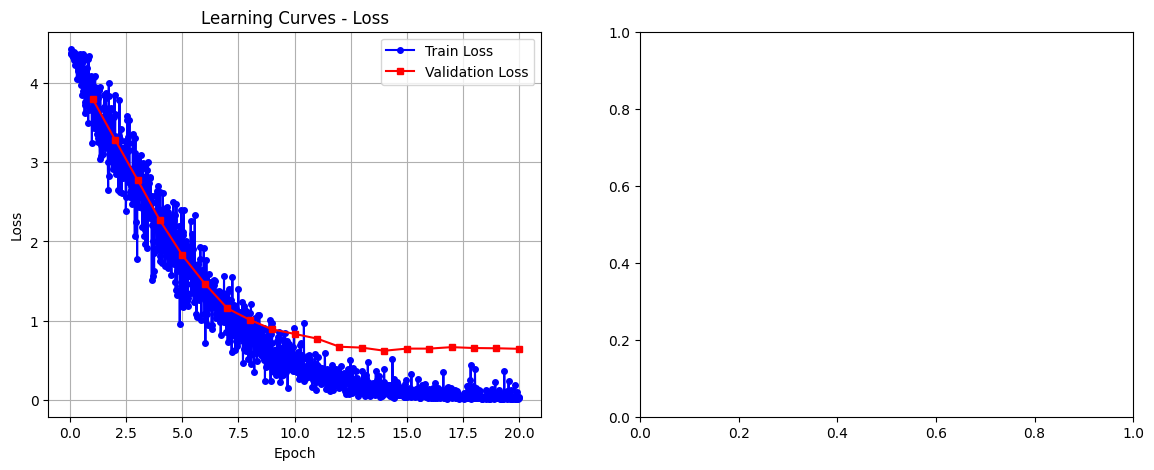

In [23]:
# Извлекаем историю обучения
log_history = trainer4.state.log_history

# Разделяем train и eval логи
train_losses = []
eval_losses = []
eval_accuracies = []
eval_f1_scores = []
epochs_train = []
epochs_eval = []

for log in log_history:
    if 'loss' in log and 'epoch' in log:
        # Training loss
        train_losses.append(log['loss'])
        epochs_train.append(log['epoch'])
    
    if 'eval_loss' in log and 'epoch' in log:
        # Evaluation metrics
        eval_losses.append(log['eval_loss'])
        eval_accuracies.append(log.get('eval_accuracy', None))
        eval_f1_scores.append(log.get('eval_f1_weighted', None))
        epochs_eval.append(log['epoch'])

# Создаем графики
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Loss
axes[0].plot(epochs_train, train_losses, 'b-', label='Train Loss', marker='o', markersize=4)
axes[0].plot(epochs_eval, eval_losses, 'r-', label='Validation Loss', marker='s', markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Learning Curves - Loss')
axes[0].legend()
axes[0].grid(True)

In [24]:
print("🔮 Делаем предсказания на тестовой выборке...")
model4 = model4.to('mps')
predictions = trainer4.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_labels

# f1_macro = f1_score(y_true, y_pred, average='macro')
# f1_weighted = f1_score(y_true, y_pred, average='weighted')
accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

print(f"\n📊 Общие метрики:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  precision: {precision:.4f}")
print(f"  recall: {recall:.4f}")
print(f"  f1: {f1:.4f}")

training_results[model_name] = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1
}

🔮 Делаем предсказания на тестовой выборке...



📊 Общие метрики:
  Accuracy: 0.7867
  precision: 0.8489
  recall: 0.7867
  f1: 0.8066


In [25]:
training_results

{'ai-forever/ruElectra-medium': {'accuracy': 0.7866666666666666,
  'precision': 0.8488888888888888,
  'recall': 0.7866666666666666,
  'f1': 0.8066031746031745}}

In [25]:
results = {
   "cointegrated/rubert-tiny2":{
      "accuracy":0.8,
      "precision":0.8744444444444444,
      "recall":0.8,
      "f1":0.818984126984127
   },
   "DeepPavlov/rubert-base-cased":{
      "accuracy":0.8666666666666667,
      "precision":0.9333333333333333,
      "recall":0.8666666666666667,
      "f1":0.8859682539682538
   },
   "ai-forever/ruElectra-small":{
      "accuracy":0.21333333333333335,
      "precision":0.1497222222222222,
      "recall":0.21333333333333335,
      "f1":0.16121509209744503
   },
   "ai-forever/ruElectra-medium":{
      "accuracy":0.7866666666666666,
      "precision":0.8488888888888888,
      "recall":0.7866666666666666,
      "f1":0.8066031746031745
   }
}
results

{'cointegrated/rubert-tiny2': {'accuracy': 0.8,
  'precision': 0.8744444444444444,
  'recall': 0.8,
  'f1': 0.818984126984127},
 'DeepPavlov/rubert-base-cased': {'accuracy': 0.8666666666666667,
  'precision': 0.9333333333333333,
  'recall': 0.8666666666666667,
  'f1': 0.8859682539682538},
 'ai-forever/ruElectra-small': {'accuracy': 0.21333333333333335,
  'precision': 0.1497222222222222,
  'recall': 0.21333333333333335,
  'f1': 0.16121509209744503},
 'ai-forever/ruElectra-medium': {'accuracy': 0.7866666666666666,
  'precision': 0.8488888888888888,
  'recall': 0.7866666666666666,
  'f1': 0.8066031746031745}}